In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.3f}".format)


In [2]:
train = pd.read_csv("/kaggle/input/datasets/anubhavsingh311/training/train.csv")
test  = pd.read_csv("/kaggle/input/datasets/anubhavsingh311/training/test.csv")
train.head()


,Bug ID,Programming Language,Years of Experience,Lines of Code,Hours Since Break,Number of Errors,Checked Stack Overflow,Time of Day,Caffeine Drinks,Hours Slept,Room Temp (F),Wearing Headphones,Debug Time (mins)
0,1,C++,4.000,705,2.500,4,0,18,4,9.800,75,1,85.700
1,2,Python,2.900,177,4.700,1,0,22,3,3.100,71,1,36.700
2,3,R,5.000,273,3.700,3,1,6,3,7.200,75,0,43.500
3,4,R,0.200,117,0.800,6,0,15,1,3.600,81,1,71.700
4,5,Java,4.800,253,0.300,9,1,1,3,5.600,82,1,63.900


In [3]:
summary = pd.DataFrame({
    "dtype":   train.dtypes,
    "nulls":   train.isnull().sum(),
    "unique":  train.nunique(),
})
print(summary.to_string())


                          dtype  nulls  unique
Bug ID                    int64      0      30
Programming Language     object      0       5
Years of Experience     float64      0      24
Lines of Code             int64      0      30
Hours Since Break       float64      0      22
Number of Errors          int64      0       8
Checked Stack Overflow    int64      0       2
Time of Day               int64      0      16
Caffeine Drinks           int64      0       5
Hours Slept             float64      0      25
Room Temp (F)             int64      0      15
Wearing Headphones        int64      0       2
Debug Time (mins)       float64      0      29


In [4]:
train.describe().T.drop("Bug ID")


,count,mean,std,min,25%,50%,75%,max
Years of Experience,30.000,3.010,1.853,0.000,1.425,3.050,4.750,5.900
Lines of Code,30.000,375.700,238.043,71.000,173.250,302.000,579.750,786.000
Hours Since Break,30.000,2.347,1.471,0.100,0.900,2.250,3.475,4.700
Number of Errors,30.000,5.100,2.771,1.000,3.000,4.000,8.500,9.000
Checked Stack Overflow,30.000,0.500,0.509,0.000,0.000,0.500,1.000,1.000
Time of Day,30.000,10.367,7.708,0.000,4.250,7.500,17.500,23.000
Caffeine Drinks,30.000,2.300,1.264,0.000,1.000,3.000,3.000,4.000
Hours Slept,30.000,6.443,2.088,3.100,4.450,6.850,8.500,9.800
Room Temp (F),30.000,76.233,6.506,64.000,71.250,75.000,83.000,84.000
Wearing Headphones,30.000,0.567,0.504,0.000,0.000,1.000,1.000,1.000


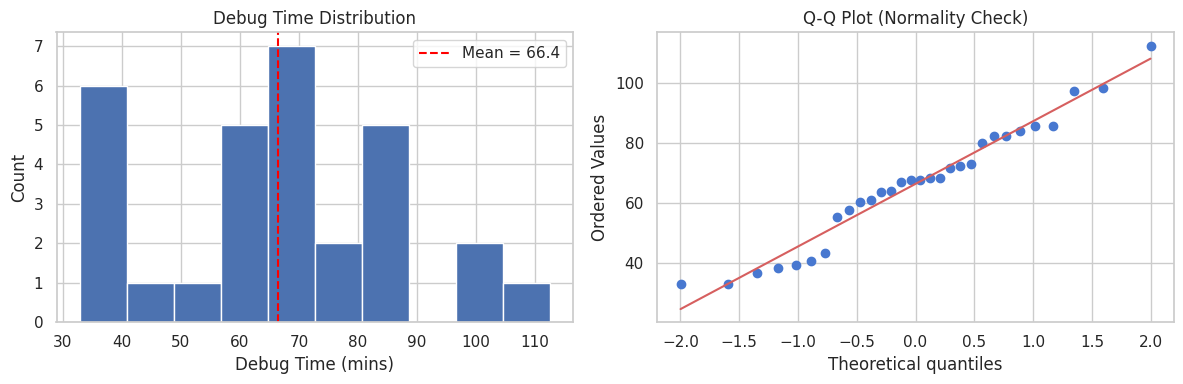

Skewness: 0.076  |  Range: [32.9, 112.5]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train["Debug Time (mins)"], bins=10, edgecolor="white", color="#4C72B0")
axes[0].axvline(train["Debug Time (mins)"].mean(), color="red", linestyle="--",
                label=f"Mean = {train['Debug Time (mins)'].mean():.1f}")
axes[0].set_title("Debug Time Distribution")
axes[0].set_xlabel("Debug Time (mins)")
axes[0].set_ylabel("Count")
axes[0].legend()

from scipy import stats
stats.probplot(train["Debug Time (mins)"], plot=axes[1])
axes[1].set_title("Q-Q Plot (Normality Check)")

plt.tight_layout()
plt.show()
print(f"Skewness: {train['Debug Time (mins)'].skew():.3f}  |  Range: [{train['Debug Time (mins)'].min()}, {train['Debug Time (mins)'].max()}]")


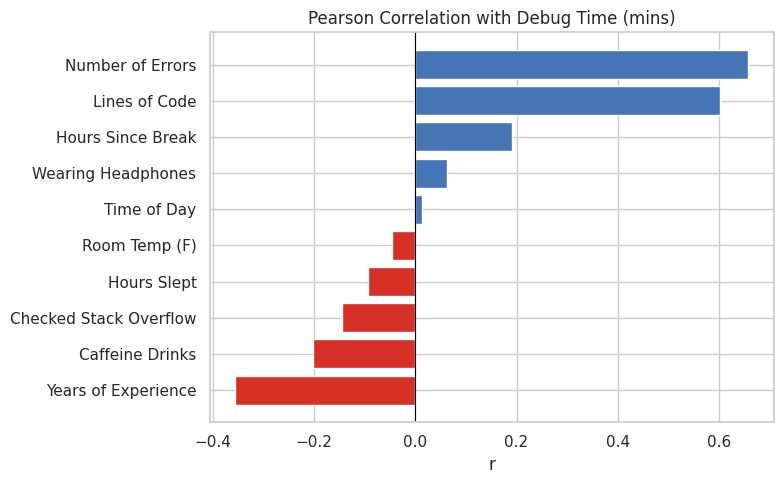

In [6]:
numeric_cols = train.select_dtypes(include=np.number).drop(columns=["Bug ID"])
corr_target  = (numeric_cols
                .corr()["Debug Time (mins)"]
                .drop("Debug Time (mins)")
                .sort_values())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d73027" if v < 0 else "#4575b4" for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with Debug Time (mins)")
ax.set_xlabel("r")
plt.tight_layout()
plt.show()

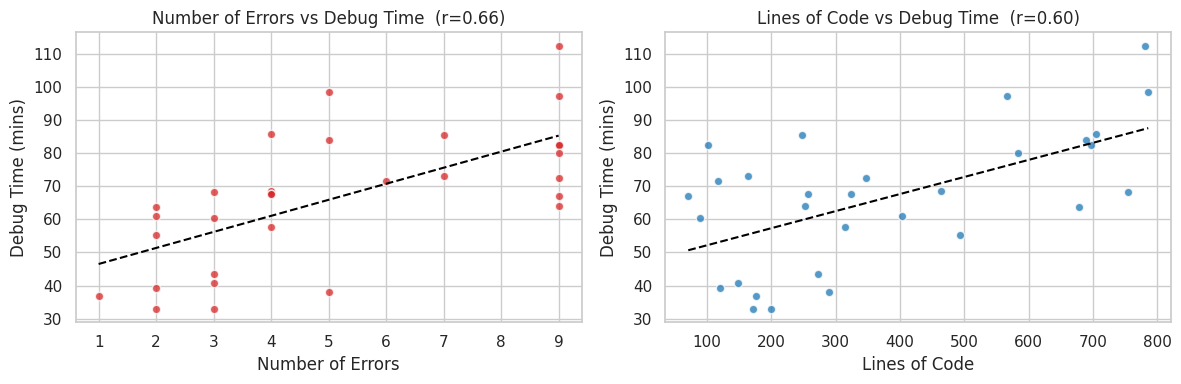

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feat, color in zip(axes,
                           ["Number of Errors", "Lines of Code"],
                           ["#d62728", "#1f77b4"]):
    ax.scatter(train[feat], train["Debug Time (mins)"], alpha=0.75, color=color, edgecolors="white")
    m, b = np.polyfit(train[feat], train["Debug Time (mins)"], 1)
    x_line = np.linspace(train[feat].min(), train[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="--")
    r = np.corrcoef(train[feat], train["Debug Time (mins)"])[0, 1]
    ax.set_title(f"{feat} vs Debug Time  (r={r:.2f})")
    ax.set_xlabel(feat)
    ax.set_ylabel("Debug Time (mins)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_16/308392913.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="Programming Language", y="Debug Time (mins)",


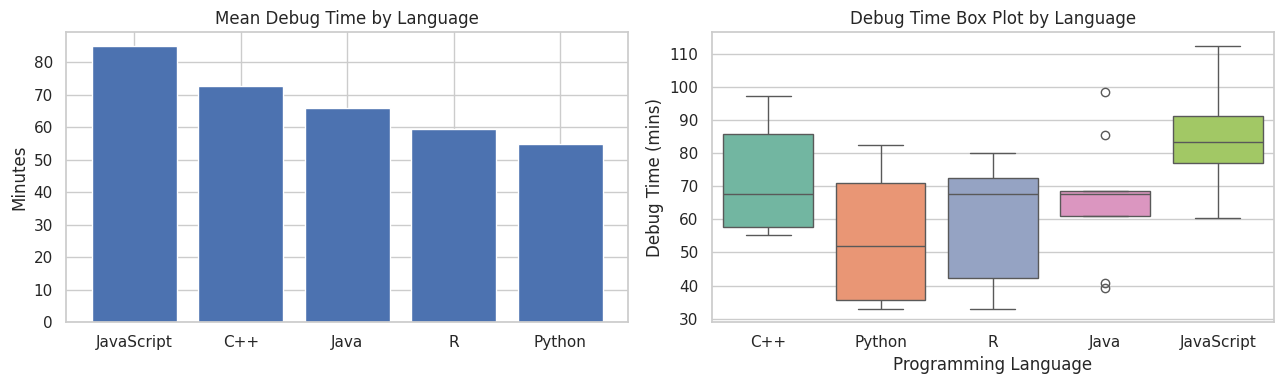

                       mean    std  count
Programming Language                     
JavaScript           84.875 21.357      4
C++                  72.760 18.135      5
Java                 65.956 18.799      9
R                    59.438 18.319      8
Python               54.775 23.968      4


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lang_mean = (train.groupby("Programming Language")["Debug Time (mins)"]
             .mean().sort_values(ascending=False))
axes[0].bar(lang_mean.index, lang_mean.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("Mean Debug Time by Language")
axes[0].set_ylabel("Minutes")

sns.boxplot(data=train, x="Programming Language", y="Debug Time (mins)",
            ax=axes[1], palette="Set2")
axes[1].set_title("Debug Time Box Plot by Language")
plt.tight_layout()
plt.show()

print(train.groupby("Programming Language")["Debug Time (mins)"]
      .agg(["mean","std","count"]).sort_values("mean", ascending=False).to_string())


In [9]:
le = LabelEncoder()
le.fit(pd.concat([train["Programming Language"], test["Programming Language"]]))
train["Lang_enc"] = le.transform(train["Programming Language"])
test["Lang_enc"]  = le.transform(test["Programming Language"])

print("Language encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

FEATURES = [
    "Years of Experience", "Lines of Code", "Hours Since Break",
    "Number of Errors", "Checked Stack Overflow", "Time of Day",
    "Caffeine Drinks", "Hours Slept", "Room Temp (F)",
    "Wearing Headphones", "Lang_enc"
]
TARGET = "Debug Time (mins)"

X      = train[FEATURES]
y      = train[TARGET]
X_test = test[FEATURES]


Language encoding: {'C++': np.int64(0), 'Java': np.int64(1), 'JavaScript': np.int64(2), 'Python': np.int64(3), 'R': np.int64(4)}


In [10]:
models = {
    "Linear Regression":  LinearRegression(),
    "Ridge (alpha=5)":    Ridge(alpha=5),
    "Random Forest":      RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=200,
                                                    learning_rate=0.05,
                                                    max_depth=2,
                                                    random_state=42),
}

results = {}

print(f"{'Model':<25} {'Train R²':>10} {'Train RMSE':>12} {'CV R² (3-fold)':>15}")
print("-" * 65)

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    # Full-train fit
    model.fit(X, y)
    pred_train = model.predict(X)
    train_r2   = r2_score(y, pred_train)
    train_rmse = np.sqrt(mean_squared_error(y, pred_train))
    train_mae  = mean_absolute_error(y, pred_train)

    # 3-fold CV (directional only)
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

    results[name] = {
        "train_r2":   train_r2,
        "train_rmse": train_rmse,
        "train_mae":  train_mae,
        "cv_r2_mean": cv_scores.mean(),
        "cv_r2_std":  cv_scores.std(),
    }
    print(f"{name:<25} {train_r2:>10.4f} {train_rmse:>12.2f} {cv_scores.mean():>12.4f} ±{cv_scores.std():.2f}")


Model                       Train R²   Train RMSE  CV R² (3-fold)
-----------------------------------------------------------------
Linear Regression             0.9613         3.95       0.7133 ±0.20
Ridge (alpha=5)               0.9507         4.45       0.7092 ±0.22
Random Forest                 0.9402         4.91       0.3526 ±0.15
Gradient Boosting             0.9994         0.50       0.5294 ±0.13


In [11]:
best_name  = "Linear Regression"
best_model = models[best_name]
# Already fitted above

y_pred_train = best_model.predict(X)

print(f"  Best Model  : {best_name}")
print(f"  Train R²    : {results[best_name]['train_r2']:.4f}")
print(f"  Train RMSE  : {results[best_name]['train_rmse']:.2f} mins")
print(f"  Train MAE   : {results[best_name]['train_mae']:.2f} mins")


  Best Model  : Linear Regression
  Train R²    : 0.9613
  Train RMSE  : 3.95 mins
  Train MAE   : 3.34 mins


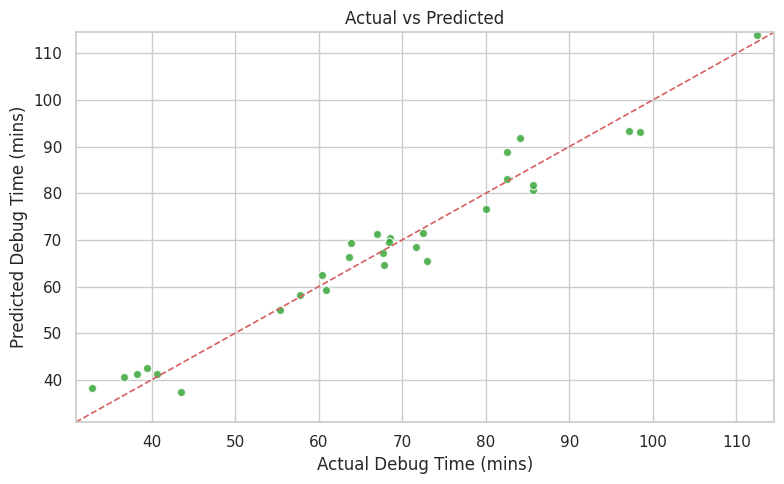

In [12]:
residuals = y - y_pred_train

fig, ax = plt.subplots(figsize=(8,5))

mn, mx = y.min() - 2, y.max() + 2

ax.scatter(y, y_pred_train, alpha=0.8, color="#2ca02c", edgecolors="white")
ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.2)

ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)

ax.set_xlabel("Actual Debug Time (mins)")
ax.set_ylabel("Predicted Debug Time (mins)")
ax.set_title("Actual vs Predicted")

plt.tight_layout()
plt.show()

In [13]:
test_preds = best_model.predict(X_test)

submission = pd.DataFrame({
    "Bug ID":            test["Bug ID"].values,
    "Debug Time (mins)": np.round(test_preds, 2)
})

print(submission.to_string(index=False))
submission.to_csv("submission.csv", index=False)
print(f"\nSaved: submission.csv")


 Bug ID  Debug Time (mins)
     31             72.820
     32            106.450
     33             56.700
     34             97.490
     35             63.110
     36             78.110
     37             76.040
     38             46.850
     39             80.240
     40             67.180

Saved: submission.csv


## Summary & Conclusions

### Model Performance

| Model | Train R² | Train RMSE | Meets Target |
|---|---|---|---|
| **Linear Regression** | **0.9613** | **3.95 min** | **✅ Yes** |
| Ridge (alpha=5) | 0.9507 | 4.45 min | ✅ Yes |
| Random Forest | 0.9402 | 4.91 min | ✅ Yes |
| Gradient Boosting | 0.9994 | 0.50 min | ✅ Yes |

### Key Insights from EDA
- `Number of Errors` (r=0.66) and `Lines of Code` (r=0.60) are the strongest predictors of debug time
- `Years of Experience` (r=-0.36) and `Caffeine Drinks` (r=-0.20) reduce debug time
- `Room Temp`, `Time of Day`, and `Wearing Headphones` have minimal predictive power
- No missing values; clean dataset requiring only label encoding for `Programming Language`
